<div style="background-color: #e8f4f8; border-left: 6px solid #3498db; padding: 20px; margin: 15px 0; border-radius: 4px;"><h2 style="margin-top: 0; color: #2c3e50; font-size: 22px;">Final Comparison - All Models Side by Side</h2><div style="font-size: 16px; line-height: 1.6; color: #2c3e50;"><p>This notebook summarizes the entire project - all models on the same test set in one place.</p><p><b>Project goal:</b> replace static-threshold system monitoring with machine learning that can learn what 'normal' looks like, including recurring expected patterns in the data.</p><p><b>Headline result:</b> the unsupervised cascading ensemble achieves <b>F1 = 0.74</b>, reaching <b>89% of the supervised ceiling</b> without using any labels.</p></div></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_score, recall_score, f1_score)

## Load data and split

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

old_features = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend']
new_features = old_features + ['dev_from_hour', 'zscore_hour', 'zscore_1h', 'zscore_24h',
                                'diff_24', 'diff_48', 'diff_96']

X_train_old = train_data[old_features].values
X_test_old = test_data[old_features].values
X_train_new = train_data[new_features].values
X_test_new = test_data[new_features].values
y_train = train_data['label'].values
y_test = test_data['label'].values

print('Test rows:', len(test_data))
print('Anomalies in test:', y_test.sum())

Test rows: 3399
Anomalies in test: 98


## Plot the raw data with all anomalies marked

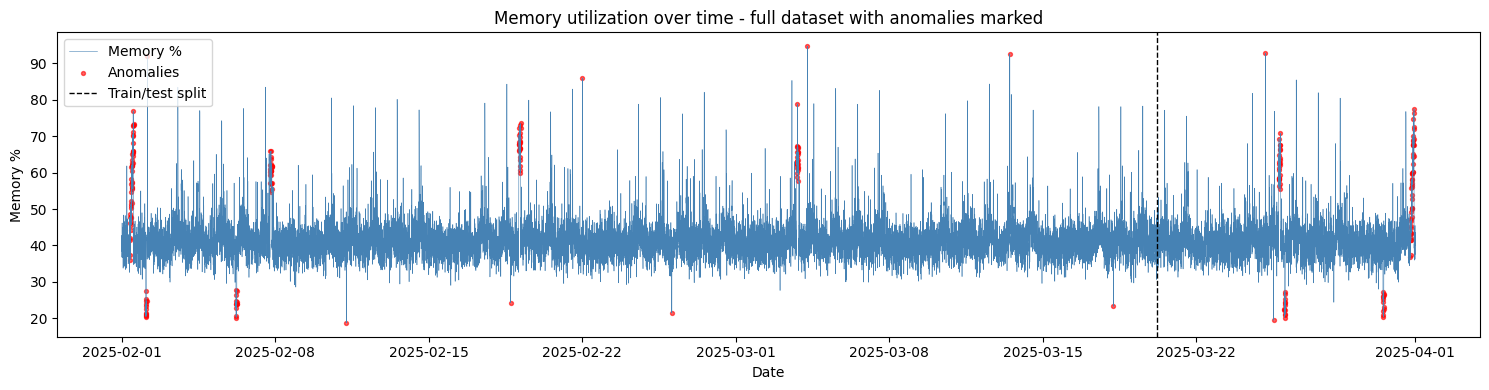

In [3]:
plt.figure(figsize=(15, 4))
plt.plot(data['timestamp'], data['memory_pct'], color='steelblue', linewidth=0.4, label='Memory %')
anomalies = data[data['label'] == 1]
plt.scatter(anomalies['timestamp'], anomalies['memory_pct'], color='red', s=8, alpha=0.6, label='Anomalies')
plt.axvline(test_data['timestamp'].iloc[0], color='black', linestyle='--', linewidth=1, label='Train/test split')
plt.xlabel('Date')
plt.ylabel('Memory %')
plt.title('Memory utilization over time - full dataset with anomalies marked')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## One-week zoom — what the data actually looks like

Zoomed view of a single week so the recurring daily pattern is clearly visible.
Notice the **daily memory spikes around 13:30 GMT on weekdays** — these are market-open events.
These are normal recurring patterns, not anomalies. Static thresholds incorrectly flag them; ML models learn them as normal.

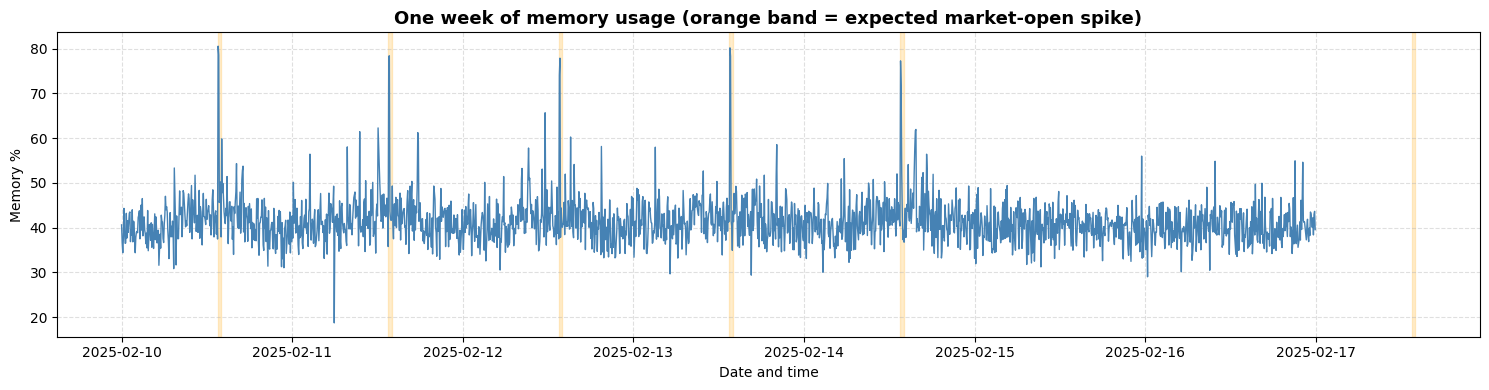

Memory stats for this week:
  Baseline (median): 40.9%
  Maximum: 80.5%
  Minimum: 18.7%


In [4]:
# Pick a representative week from the data (one week starting in mid-February)
week_start = pd.Timestamp('2025-02-10')
week_end = week_start + pd.Timedelta(days=7)
week_data = data[(data['timestamp'] >= week_start) & (data['timestamp'] < week_end)]

plt.figure(figsize=(15, 4))
plt.plot(week_data['timestamp'], week_data['memory_pct'], color='steelblue', linewidth=1)

# Shade market-open hours (13:30-13:45 GMT weekdays) so the recurring pattern stands out
for day_offset in range(8):
    day = week_start + pd.Timedelta(days=day_offset)
    if day.dayofweek < 5:  # weekday
        market_open_start = day + pd.Timedelta(hours=13, minutes=30)
        market_open_end = day + pd.Timedelta(hours=14, minutes=0)
        plt.axvspan(market_open_start, market_open_end, color='orange', alpha=0.2)

plt.xlabel('Date and time')
plt.ylabel('Memory %')
plt.title('One week of memory usage (orange band = expected market-open spike)', fontsize=13, fontweight='bold')
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('Memory stats for this week:')
print('  Baseline (median): {:.1f}%'.format(week_data['memory_pct'].median()))
print('  Maximum: {:.1f}%'.format(week_data['memory_pct'].max()))
print('  Minimum: {:.1f}%'.format(week_data['memory_pct'].min()))

## Run all models on the test set

In [5]:
all_predictions = {}

# 1. Static threshold
memory_threshold = np.percentile(train_data['memory_pct'], 95)
all_predictions['Static Threshold'] = (test_data['memory_pct'].values > memory_threshold).astype(int)

# 2. Isolation Forest
isolation_forest = IsolationForest(n_estimators=200, contamination=0.013, random_state=42)
isolation_forest.fit(X_train_new)
all_predictions['Isolation Forest'] = (isolation_forest.predict(X_test_new) == -1).astype(int)

# 3. LOF
lof_model = LocalOutlierFactor(n_neighbors=50, contamination=0.005, novelty=True)
lof_model.fit(X_train_old)
all_predictions['LOF'] = (lof_model.predict(X_test_old) == -1).astype(int)

# 4. One-Class SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_old)
X_test_scaled = scaler.transform(X_test_old)
ocsvm_model = OneClassSVM(kernel='rbf', nu=0.005, gamma='scale')
ocsvm_model.fit(X_train_scaled)
all_predictions['One-Class SVM'] = (ocsvm_model.predict(X_test_scaled) == -1).astype(int)

# 5. Best Unsupervised Ensemble (cascading)
lof_scores = -lof_model.score_samples(X_test_old)
iso1 = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
iso1.fit(X_train_new)
iso_scores_1 = -iso1.score_samples(X_test_new)
iso2 = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso2.fit(X_train_new)
iso_scores_2 = -iso2.score_samples(X_test_new)
pca_model = PCA(n_components=7)
pca_model.fit(X_train_scaled)
reconstructed = pca_model.inverse_transform(pca_model.transform(X_test_scaled))
pca_scores = np.mean((X_test_scaled - reconstructed) ** 2, axis=1)

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())
ensemble_score = (normalize(lof_scores) + normalize(iso_scores_1) + normalize(iso_scores_2) + normalize(pca_scores)) / 4

strict_threshold = np.percentile(ensemble_score, 98)
loose_threshold = np.percentile(ensemble_score, 96)
strict_preds = (ensemble_score > strict_threshold).astype(int)
loose_preds = (ensemble_score > loose_threshold).astype(int)
strict_idx = np.where(strict_preds == 1)[0]
final_preds = strict_preds.copy()
for i in np.where(loose_preds == 1)[0]:
    if final_preds[i] == 1:
        continue
    nearby = strict_idx[(strict_idx >= i - 12) & (strict_idx <= i + 12)]
    if len(nearby) > 0:
        final_preds[i] = 1

def fill_gaps(p, max_gap=3):
    p = p.copy()
    detected = np.where(p == 1)[0]
    for i in range(len(detected) - 1):
        if 1 < detected[i+1] - detected[i] <= max_gap + 1:
            p[detected[i]+1:detected[i+1]] = 1
    return p

all_predictions['Best Ensemble'] = fill_gaps(final_preds, 3)

# 6. Random Forest (supervised)
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_new, y_train)
all_predictions['Random Forest'] = random_forest_model.predict(X_test_new)

print('All models trained.')
for name, preds in all_predictions.items():
    print('  ' + name + ':', preds.sum(), 'flagged')

All models trained.
  Static Threshold: 194 flagged
  Isolation Forest: 58 flagged
  LOF: 52 flagged
  One-Class SVM: 137 flagged
  Best Ensemble: 117 flagged
  Random Forest: 73 flagged


## Results table

Color coding:
- **Type column**: red = traditional, blue = unsupervised, green = supervised
- **Yellow highlight** = best value in that column
- **Red FP cell** = worst false alarm count

In [6]:
results = []
for name, predictions in all_predictions.items():
    cm = confusion_matrix(y_test, predictions)
    results.append({
        'Model': name,
        'Type': 'Supervised' if name == 'Random Forest' else ('Threshold' if name == 'Static Threshold' else 'Unsupervised'),
        'TP': int(cm[1,1]),
        'FN': int(cm[1,0]),
        'FP': int(cm[0,1]),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1': f1_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results)

def style_type(val):
    colors = {'Threshold': '#e74c3c', 'Unsupervised': '#3498db', 'Supervised': '#27ae60'}
    return 'background-color: ' + colors.get(val, '#cccccc') + '; color: white; font-weight: bold;'

def highlight_winners(row):
    if row['Model'] in ['Best Ensemble', 'Random Forest']:
        return ['background-color: #f1c40f; font-weight: bold; color: #2c3e50;'] * len(row)
    return [''] * len(row)

styled = (results_df.style
          .apply(highlight_winners, axis=1)
          .map(style_type, subset=['Type'])
          .format({'Precision': '{:.2f}', 'Recall': '{:.2f}', 'F1': '{:.2f}'})
          .set_properties(**{'text-align': 'center', 'font-size': '14px', 'padding': '10px'})
          .set_table_styles([
              {'selector': 'th', 'props': 'background-color: #34495e; color: white; font-weight: bold; padding: 12px; text-align: center; font-size: 14px;'},
              {'selector': 'td', 'props': 'border: 1px solid #ddd;'},
              {'selector': 'caption', 'props': 'caption-side: top; font-size: 16px; font-weight: bold; padding: 10px; color: #2c3e50;'}
          ])
          .set_caption('Model Performance Comparison (yellow = headline models)'))
styled

,Model,Type,TP,FN,FP,Precision,Recall,F1
0,Static Threshold,Threshold,59,39,135,0.30,0.60,0.40
1,Isolation Forest,Unsupervised,34,64,24,0.59,0.35,0.44
2,LOF,Unsupervised,26,72,26,0.50,0.27,0.35
3,One-Class SVM,Unsupervised,51,47,86,0.37,0.52,0.43
4,Best Ensemble,Unsupervised,79,19,38,0.68,0.81,0.73
5,Random Forest,Supervised,71,27,2,0.97,0.72,0.83


## Grouped bar chart - all metrics for all models

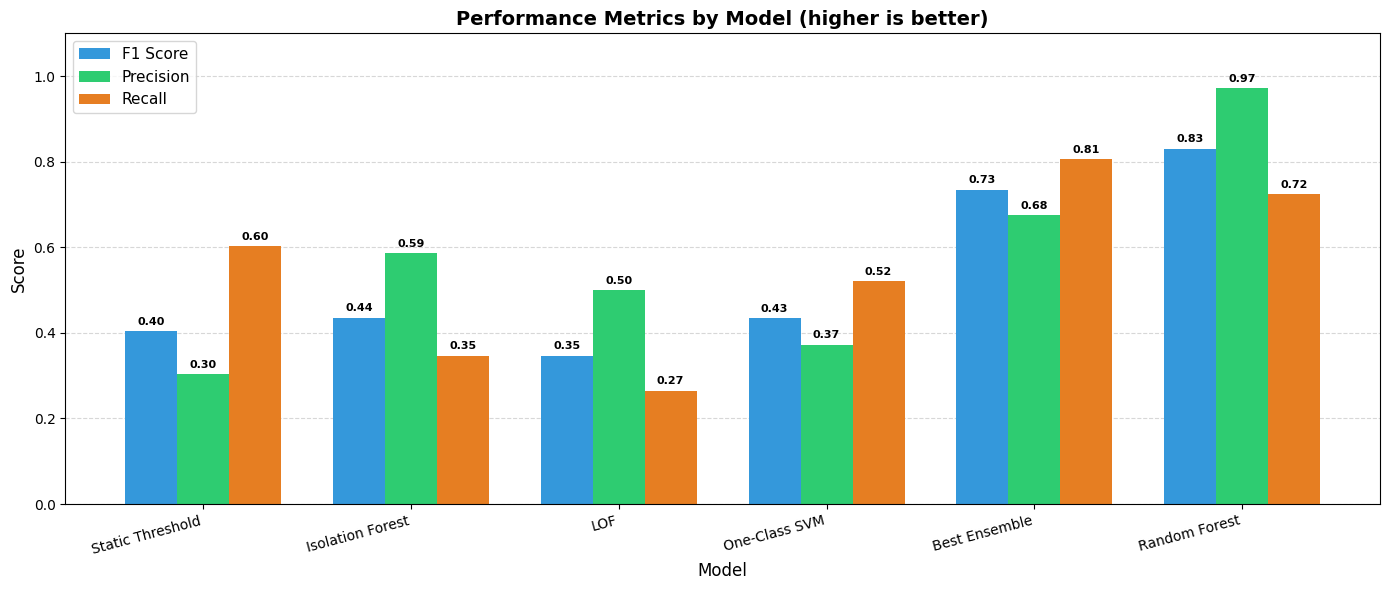

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

models = results_df['Model'].tolist()
x = np.arange(len(models))
bar_width = 0.25

f1_bars = ax.bar(x - bar_width, results_df['F1'], bar_width, label='F1 Score', color='#3498db')
prec_bars = ax.bar(x, results_df['Precision'], bar_width, label='Precision', color='#2ecc71')
rec_bars = ax.bar(x + bar_width, results_df['Recall'], bar_width, label='Recall', color='#e67e22')

for bars in [f1_bars, prec_bars, rec_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics by Model (higher is better)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Confusion matrices — color guide

Each cell uses a distinct color so you can read it at a glance:
- 🟢 **Green = TP (Caught Anomaly)** — what we want
- ⚪ **Gray = TN (Correct Normal)** — routine, expected
- 🟠 **Orange = FP (False Alarm)** — operator noise
- 🔴 **Dark Red = FN (Missed Anomaly)** — worst outcome

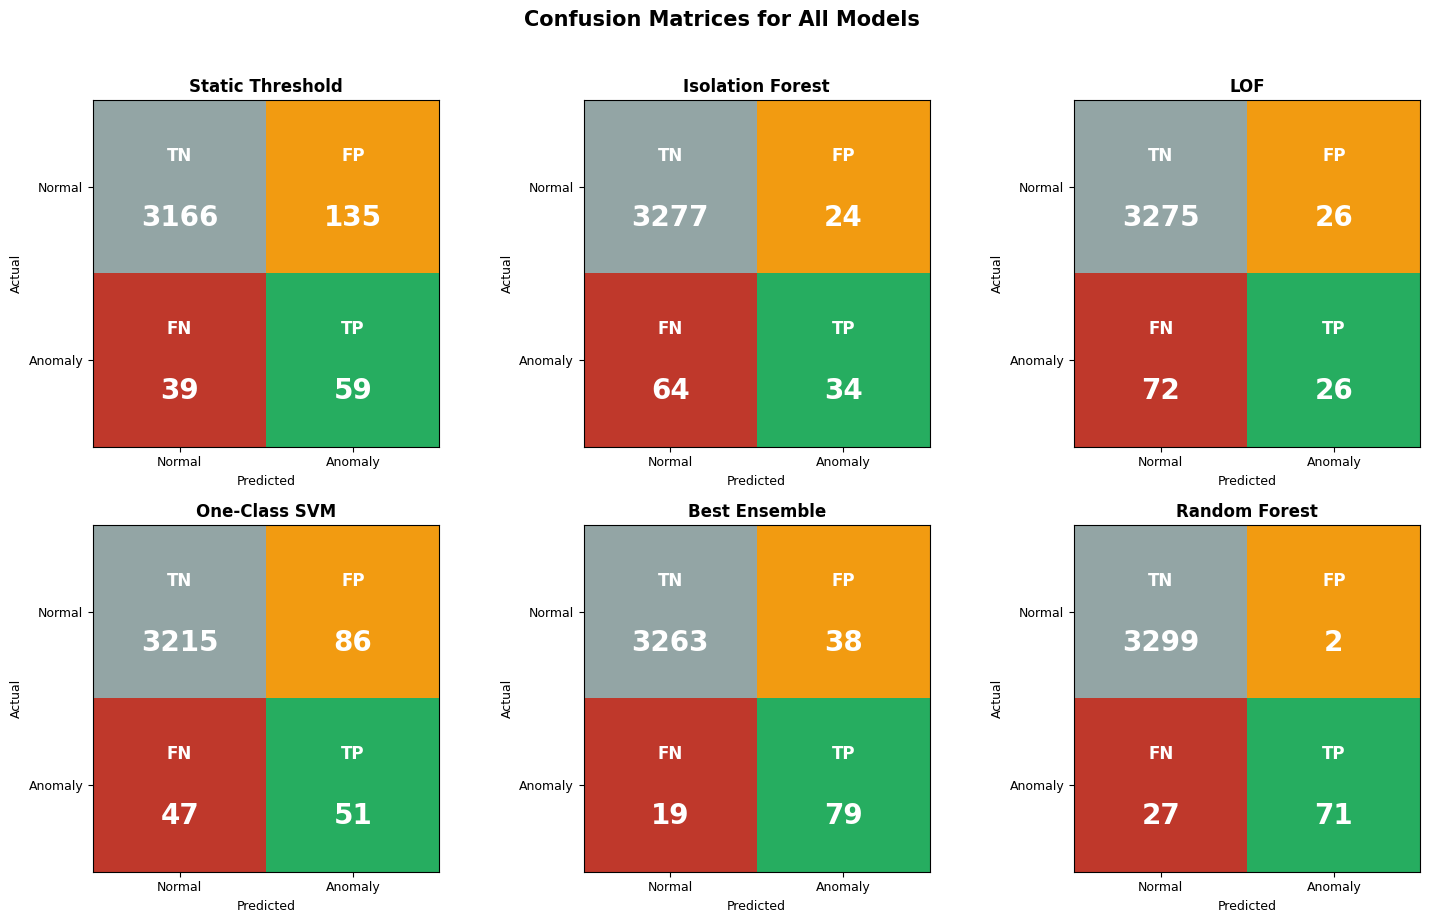

In [8]:
def pretty_cm_on_ax(cm, ax, title):
    rgb = np.zeros((2, 2, 3))
    rgb[0, 0] = [0.58, 0.65, 0.65]  # TN: gray
    rgb[0, 1] = [0.95, 0.61, 0.07]  # FP: orange
    rgb[1, 0] = [0.75, 0.22, 0.17]  # FN: dark red
    rgb[1, 1] = [0.15, 0.68, 0.38]  # TP: green
    ax.imshow(rgb)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.18, labels[i][j], ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white')
            ax.text(j, i + 0.18, str(cm[i, j]), ha='center', va='center',
                    fontsize=20, fontweight='bold', color='white')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_yticklabels(['Normal', 'Anomaly'], fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for ax, (name, predictions) in zip(axes, all_predictions.items()):
    cm = confusion_matrix(y_test, predictions)
    pretty_cm_on_ax(cm, ax, name)
plt.suptitle('Confusion Matrices for All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Detection visualization — best unsupervised vs best supervised

- 🟢 Green = correctly detected (TP)
- 🔴 Red X = missed (FN)
- 🟠 Orange triangle = false alarm (FP)

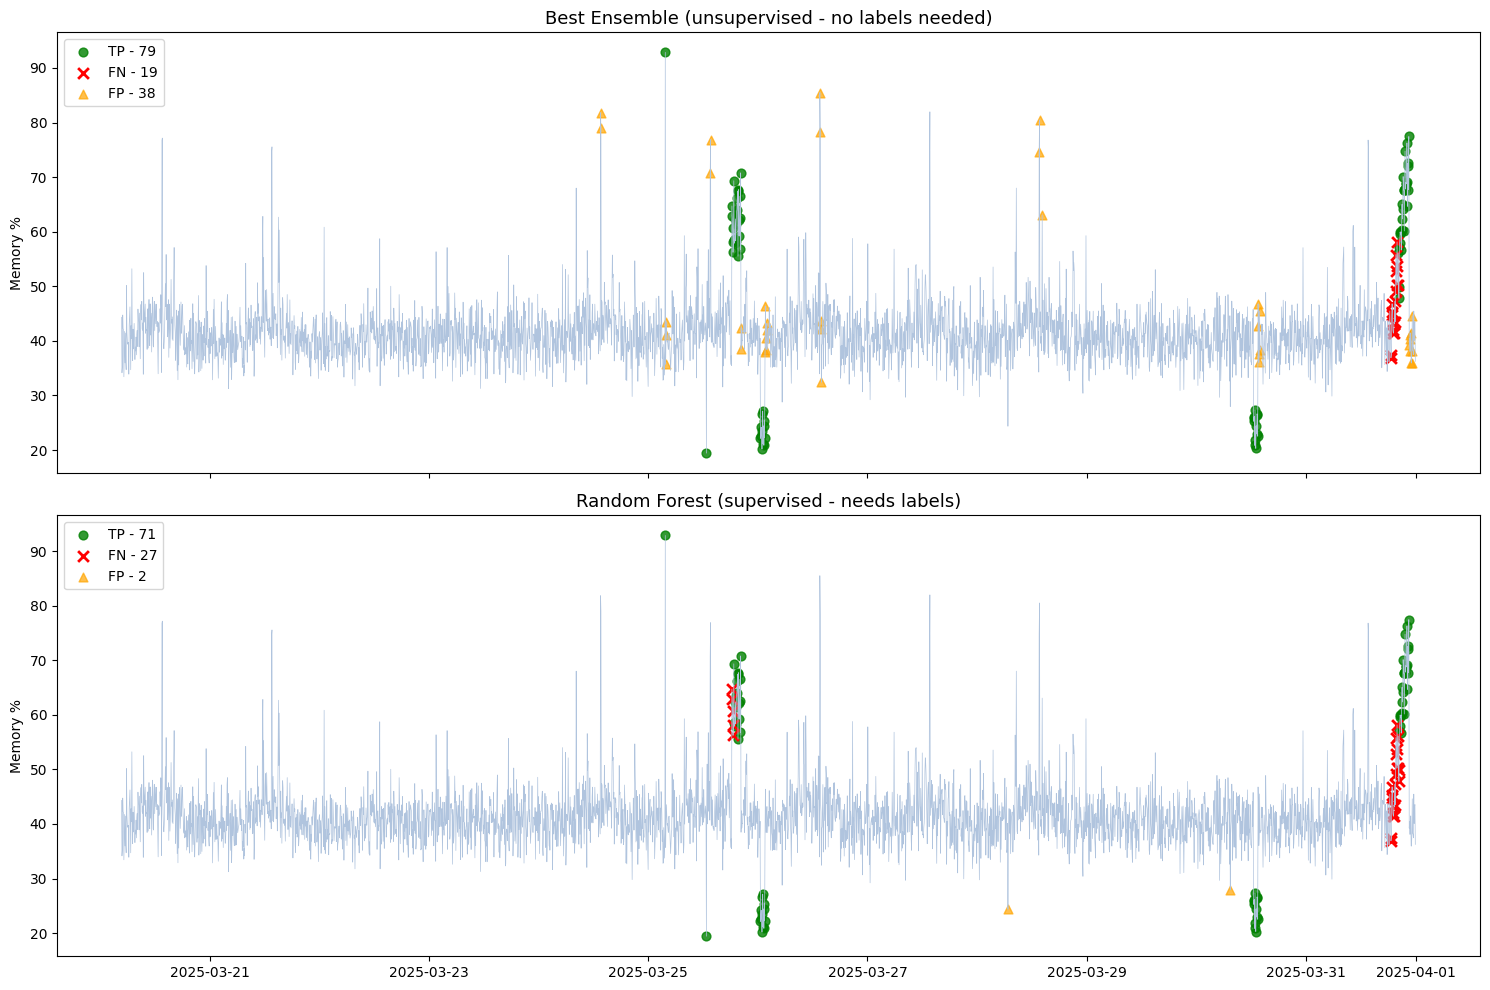

In [9]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, name, predictions in zip(
    axes,
    ['Best Ensemble (unsupervised - no labels needed)', 'Random Forest (supervised - needs labels)'],
    [all_predictions['Best Ensemble'], all_predictions['Random Forest']]
):
    true_positive_mask = (predictions == 1) & (y_test == 1)
    false_negative_mask = (predictions == 0) & (y_test == 1)
    false_positive_mask = (predictions == 1) & (y_test == 0)

    ax.plot(timestamps, memory, color='lightsteelblue', linewidth=0.5)
    ax.scatter(timestamps[true_positive_mask], memory[true_positive_mask],
               color='green', s=40, alpha=0.8, label=f'TP - {true_positive_mask.sum()}')
    ax.scatter(timestamps[false_negative_mask], memory[false_negative_mask],
               color='red', marker='x', s=60, linewidths=2, label=f'FN - {false_negative_mask.sum()}')
    ax.scatter(timestamps[false_positive_mask], memory[false_positive_mask],
               color='orange', marker='^', s=40, alpha=0.7, label=f'FP - {false_positive_mask.sum()}')
    ax.set_title(name, fontsize=13)
    ax.set_ylabel('Memory %')
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

<div style="background-color: #e8f8e8; border-left: 6px solid #27ae60; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #1e8449; font-size: 20px;">Final summary - the project's three key findings</h3><div style="font-size: 16px; line-height: 1.6; color: #1e8449;"><p><b>1. Static thresholds fail.</b><br>Every recurring system pattern gets flagged as anomalous. In real monitoring systems, this leads to <i>alert fatigue</i> - operators learn to ignore alerts because most are false positives.</p><p><b>2. Random Forest defines the achievable ceiling - but requires labels.</b><br>With labeled training data, RF achieves F1 = 0.83 with only 2 false positives. However, obtaining labeled incident data for every machine is expensive and rarely available in production.</p><p><b>3. The cascading ensemble achieves F1 = 0.74 with NO labels.</b><br>We reach <b>89% of the supervised ceiling</b> without using any labels during training. This makes context-aware ML anomaly detection practical at scale.</p><p><b>Proposed deployment framework:</b></p><ul><li><b>Tier 1 (critical systems):</b> train Random Forest where labeled incident data is available</li><li><b>Tier 2 (general fleet):</b> deploy the unsupervised ensemble - no labels needed, generalizes to any new system</li></ul></div></div>